<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/hafta-4/YZ50Hafta4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Embedding Oluşturma

In [976]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [977]:
import os

if not os.path.exists("names.txt"):
    !wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

print("names.txt is downloaded")

names.txt is downloaded


In [978]:
words = open("names.txt", 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
chars = ['.'] + chars
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

In [979]:
num_vocab = len(chars)
context_size = 3
emb_dim = 2
hidden_dim = 100
batch_size = 32

In [980]:
X, Y = [], []

for word in words:
    context = [0] * context_size
    for ch in word + '.':
        idx = stoi[ch]
        X.append(context)
        Y.append(idx)
        context = context[1:] + [idx]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [981]:
C = torch.randn((num_vocab, emb_dim))

C[X[:5]].shape

torch.Size([5, 3, 2])

# 2. Embedding ve Ara Katmanlar ile Forward Pass

In [982]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

Elle hesaplanan loss ile Cross Entropy lossunun ayni oldugunu gosterme

In [983]:
emb = C[X]
emb.shape
hidden_layer = torch.tanh(emb.reshape(len(X), -1) @ weight1 + bias1)
logits = hidden_layer @ weight2 + bias2

counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
manual_loss = -probs[torch.arange(len(X)), Y].log().mean()

cross_entropy_loss = F.cross_entropy(logits, Y)

print(f"Elle hesaplanan loss: {manual_loss.item()} | Cross entropy ile hesaplanan loss: {cross_entropy_loss}")

Elle hesaplanan loss: 16.72646713256836 | Cross entropy ile hesaplanan loss: 16.726470947265625


# 3. Eğitim Döngüsü

In [984]:
for param in parameters:
    param.requires_grad = True

Tek bir minibatchi overfit etme

In [985]:
temp_X = X[:32]
temp_Y = Y[:32]

epochs = 100
learning_rate = 0.1

for epoch in range(epochs):
    emb = C[temp_X]
    hidden_layer = torch.tanh(emb.reshape(len(temp_X), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, temp_Y)
    if epoch % 10 == 0:
        print(f"Epochs: {epoch} | Loss: {loss}")

    for param in parameters:
        param.grad = None

    loss.backward()

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

Epochs: 0 | Loss: 17.775842666625977
Epochs: 10 | Loss: 4.3454132080078125
Epochs: 20 | Loss: 1.2727065086364746
Epochs: 30 | Loss: 0.4890214204788208
Epochs: 40 | Loss: 0.3547118902206421
Epochs: 50 | Loss: 0.32074666023254395
Epochs: 60 | Loss: 0.30477234721183777
Epochs: 70 | Loss: 0.2951887845993042
Epochs: 80 | Loss: 0.28871577978134155
Epochs: 90 | Loss: 0.284017413854599
0.28075531125068665


butun veriyi minibatchlere bolerek egitme

In [986]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [987]:
epochs = 5000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

2.600926160812378


Learning rate icin iyi bir deger secme

In [988]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [989]:
lr_exp = torch.linspace(-3, 0, 2000)
lr_vals = 10**lr_exp

In [990]:
epochs = 2000
# learning_rate = 0.1

lrs_used = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    learning_rate = lr_vals[epoch]
    lrs_used.append(lr_exp[epoch])
    loss_vals.append(loss.item())

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

6.102156639099121


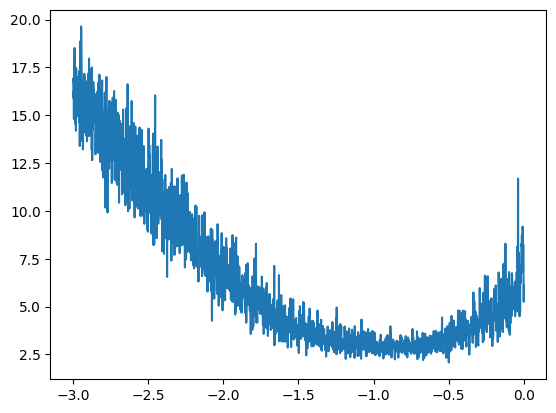

In [991]:
plt.plot(lrs_used, loss_vals);

In [992]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [993]:
epochs = 30000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

2.2245898246765137


In [994]:
def get_entire_data_loss():
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X]
    hidden_layer = torch.tanh(emb.reshape(len(X), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

print(get_entire_data_loss())

2.342721700668335


In [995]:
import random

def build_dataset(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

random.seed(42)
words_copy = words.copy()
random.shuffle(words_copy)
tr_split = int(0.8 * len(words_copy))
dev_split = int(0.9 * len(words_copy))

Xtr, Ytr = build_dataset(words_copy[:tr_split])
Xdev, Ydev = build_dataset(words_copy[tr_split:dev_split])
Xte, Yte = build_dataset(words_copy[dev_split:])

@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": {Xtr, Ytr},
        "dev": {Xdev, Ydev},
        "test": {Xte, Yte},
    }[split]
    emb = C[x]
    hidden_layer = torch.tanh(emb.reshape(len(x), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, y)
    return loss.item()

In [996]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [997]:
epochs = 30000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

2.4873669147491455


In [998]:
print(get_loss("dev"))

2.3412892818450928


In [999]:
print(get_loss("test"))

2.3385841846466064


# 4. Hidden Layer ve Embedding Boyutunu Büyütme

In [1000]:
hidden_dim = 300

In [1001]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [1002]:
epochs = 30000
learning_rate = 0.1
epoch_vals = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    epoch_vals.append(epoch)
    loss_vals.append(loss.item())

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

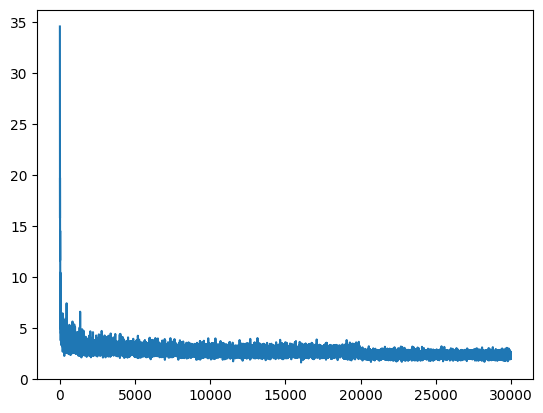

In [1003]:
plt.plot(epoch_vals, loss_vals);

In [1004]:
print(get_loss("train"))

2.333601236343384


In [1005]:
print(get_loss("dev"))

2.3340864181518555


Embedding vectorlerine gore harflerin konumu

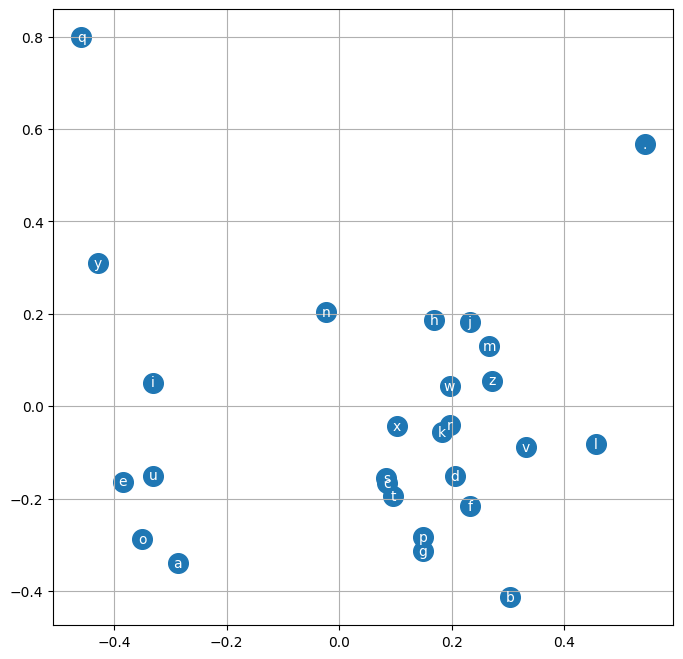

In [1006]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(len(C)):
    plt.text(C[i,0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor');

In [1007]:
hidden_dim = 200
emb_dim = 10

In [1008]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [1009]:
epochs = 100000
learning_rate = 0.1
epoch_vals = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    epoch_vals.append(epoch)
    loss_vals.append(loss.log10().item())

    if epoch > 50000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

In [1010]:
get_loss("train"), get_loss("dev"), get_loss("test")

(2.170980215072632, 2.1983189582824707, 2.193716526031494)

model ile isim uretme

In [1011]:
num_names = 20

g = torch.Generator().manual_seed(42)

for _ in range(num_names):
    name = []
    context = [0] * context_size
    while True:
        emb = C[torch.tensor(context)]
        hidden_layer = torch.tanh(emb.reshape(1, -1) @ weight1 + bias1)
        logits = hidden_layer @ weight2 + bias2
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1, generator=g).item()

        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

anuhien
tis
marian
dan
shan
silayler
kemarce
man
epiacelle
jamzi
kence
jordon
kalla
makolynna
cvahia
achalani
darcelynn
mar
tal
selixo


# 5. Başlangıc Loss'u Niye Yüksek ve Tanh Niye Bozuk ve Nasıl Düzeltilir

In [1012]:
def training_loop():
    epochs = 200000
    learning_rate = 0.1

    for epoch in range(epochs):
        idx = torch.randint(0, len(Xtr), (batch_size,))
        emb = C[Xtr[idx]]
        hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
        logits = hidden_layer @ weight2 + bias2
        loss = F.cross_entropy(logits, Ytr[idx])

        for param in parameters:
            param.grad = None

        loss.backward()

        if epoch >= 100000:
            learning_rate = 0.01

        for param in parameters:
            param.data += -learning_rate * param.grad

        if epoch % 10000 == 0:
            print(f"{epoch:7d}/{epochs:7d}: Loss = {loss.item():.4f}")

    print(f"Train loss:{get_loss("train")} | Dev loss: {get_loss("dev")} | Test loss: {get_loss("test")}")
    return

In [1013]:
def first_iteration():
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    print(f"First iteration loss: {loss.item()}")

In [1014]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [1015]:
training_loop()

      0/ 200000: Loss = 24.6592
  10000/ 200000: Loss = 2.3633
  20000/ 200000: Loss = 2.5381
  30000/ 200000: Loss = 2.3924
  40000/ 200000: Loss = 2.0950
  50000/ 200000: Loss = 2.3181
  60000/ 200000: Loss = 1.9172
  70000/ 200000: Loss = 2.3809
  80000/ 200000: Loss = 2.4039
  90000/ 200000: Loss = 2.4110
 100000/ 200000: Loss = 2.2424
 110000/ 200000: Loss = 1.8872
 120000/ 200000: Loss = 2.1734
 130000/ 200000: Loss = 2.1649
 140000/ 200000: Loss = 2.1271
 150000/ 200000: Loss = 2.2412
 160000/ 200000: Loss = 2.2471
 170000/ 200000: Loss = 2.1827
 180000/ 200000: Loss = 1.6425
 190000/ 200000: Loss = 2.2136
Train loss:2.1106069087982178 | Dev loss: 2.151244640350342 | Test loss: 2.156064987182617


Baslangic lossu niye yuksek

In [1016]:
logits = torch.zeros(10)
probs = torch.softmax(logits, dim=0)
loss = -probs[5].log()
print(logits, f"Loss: {loss.item()}")

logits = torch.randn(10)
probs = torch.softmax(logits, dim=0)
loss = -probs[5].log()
print(logits, f"Loss: {loss.item()}")

logits = torch.randn(10) * 20
probs = torch.softmax(logits, dim=0)
loss = -probs[5].log()
print(logits, f"Loss: {loss.item()}")

logits = torch.randn(10) * 100
probs = torch.softmax(logits, dim=0)
loss = -probs[5].log()
print(logits, f"Loss: {loss.item()}")

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]) Loss: 2.3025851249694824
tensor([-0.5010, -0.3162, -0.1080, -1.1271,  2.2689,  0.4359,  1.5175, -0.2970,
        -0.5169, -1.5496]) Loss: 2.554015874862671
tensor([-10.7525,  34.6716,  14.9585, -13.8761,  21.5603,  12.6462, -29.9405,
         -7.3176, -11.5383,   7.4888]) Loss: 22.025426864624023
tensor([  88.8135,  154.9232,  147.2378,  111.0318,  151.0007,   13.0797,
         -25.7870,  109.5262,  -13.6122, -195.5111]) Loss: inf


In [1017]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g) * 0.1
bias2 = torch.randn((num_vocab,),                               generator=g) * 0
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [1018]:
first_iteration()

First iteration loss: 4.165034294128418


In [1019]:
training_loop()

      0/ 200000: Loss = 4.0311
  10000/ 200000: Loss = 2.2857
  20000/ 200000: Loss = 1.9836
  30000/ 200000: Loss = 1.7665
  40000/ 200000: Loss = 2.4530
  50000/ 200000: Loss = 2.0277
  60000/ 200000: Loss = 2.1359
  70000/ 200000: Loss = 2.6201
  80000/ 200000: Loss = 2.2799
  90000/ 200000: Loss = 2.2605
 100000/ 200000: Loss = 2.2958
 110000/ 200000: Loss = 1.9265
 120000/ 200000: Loss = 2.0383
 130000/ 200000: Loss = 1.8210
 140000/ 200000: Loss = 1.9494
 150000/ 200000: Loss = 2.3956
 160000/ 200000: Loss = 2.3730
 170000/ 200000: Loss = 1.9732
 180000/ 200000: Loss = 2.1070
 190000/ 200000: Loss = 1.8989
Train loss:2.0699315071105957 | Dev loss: 2.1361963748931885 | Test loss: 2.1342692375183105


tanh niye duzgun calismiyor

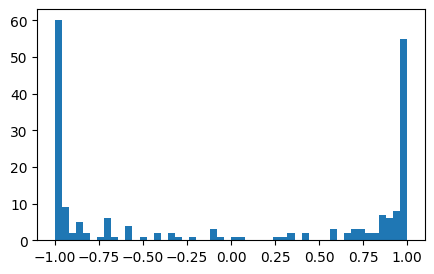

In [1020]:
plt.figure(figsize=(5,3))
plt.hist(hidden_layer.reshape(-1).tolist(), 50);

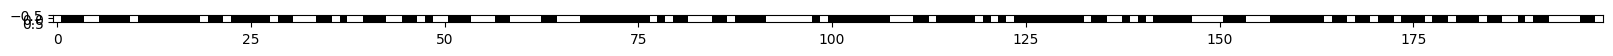

In [1021]:
plt.figure(figsize=(20,10))
plt.imshow(hidden_layer.abs() > 0.99, cmap='gray', interpolation='nearest');

In [1022]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g) * 0.2
bias1 = torch.randn((hidden_dim,),                              generator=g) * 0.01
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g) * 0.1
bias2 = torch.randn((num_vocab,),                               generator=g) * 0
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [1023]:
first_iteration()

First iteration loss: 3.574587821960449


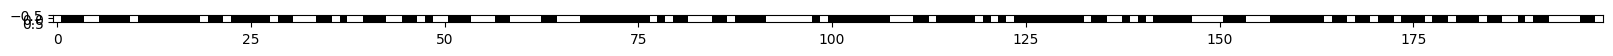

In [1024]:
plt.figure(figsize=(20,10))
plt.imshow(hidden_layer.abs() > 0.99, cmap='gray', interpolation='nearest');

In [1025]:
training_loop()

      0/ 200000: Loss = 3.5257
  10000/ 200000: Loss = 2.3118
  20000/ 200000: Loss = 2.2958
  30000/ 200000: Loss = 2.1133
  40000/ 200000: Loss = 2.1189
  50000/ 200000: Loss = 2.1144
  60000/ 200000: Loss = 2.3771
  70000/ 200000: Loss = 2.1863
  80000/ 200000: Loss = 2.1635
  90000/ 200000: Loss = 2.0445
 100000/ 200000: Loss = 2.1027
 110000/ 200000: Loss = 2.0706
 120000/ 200000: Loss = 1.9207
 130000/ 200000: Loss = 2.1402
 140000/ 200000: Loss = 1.9494
 150000/ 200000: Loss = 2.1157
 160000/ 200000: Loss = 1.8538
 170000/ 200000: Loss = 2.3963
 180000/ 200000: Loss = 1.8506
 190000/ 200000: Loss = 2.0167
Train loss:2.0375587940216064 | Dev loss: 2.105975389480591 | Test loss: 2.104624032974243


Kaimin agirliklarini ekleme

In [1026]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g) * (5/3) / (context_size * emb_dim)**0.5
bias1 = torch.randn((hidden_dim,),                              generator=g) * 0.01
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g) * 0.1
bias2 = torch.randn((num_vocab,),                               generator=g) * 0
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [1027]:
training_loop()

      0/ 200000: Loss = 3.5528
  10000/ 200000: Loss = 2.2067
  20000/ 200000: Loss = 2.1120
  30000/ 200000: Loss = 2.2140
  40000/ 200000: Loss = 2.4802
  50000/ 200000: Loss = 2.3775
  60000/ 200000: Loss = 2.1036
  70000/ 200000: Loss = 2.2981
  80000/ 200000: Loss = 1.7868
  90000/ 200000: Loss = 2.5645
 100000/ 200000: Loss = 2.5482
 110000/ 200000: Loss = 2.1377
 120000/ 200000: Loss = 2.1517
 130000/ 200000: Loss = 1.7599
 140000/ 200000: Loss = 1.8423
 150000/ 200000: Loss = 1.9269
 160000/ 200000: Loss = 1.8926
 170000/ 200000: Loss = 2.2613
 180000/ 200000: Loss = 1.8879
 190000/ 200000: Loss = 2.0778
Train loss:2.0388171672821045 | Dev loss: 2.1064858436584473 | Test loss: 2.1043431758880615


# 6. Batchnorm Katmanlarını Ekleme

In [1028]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g) * (5/3) / (context_size * emb_dim)**0.5
#bias1 = torch.randn((hidden_dim,),                              generator=g) * 0.01
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g) * 0.1
bias2 = torch.randn((num_vocab,),                               generator=g) * 0

bngain = torch.ones((1, hidden_dim))
bnbias = torch.zeros((1, hidden_dim))
bnmean_running = torch.zeros(1, hidden_dim)
bnstd_running = torch.ones((1, hidden_dim))

parameters = [C, weight1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [1029]:
epochs = 200000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    embcat = emb.reshape(batch_size, -1)
    hpreact = embcat @ weight1# + bias1
    bnmeani = hpreact.mean(dim=0, keepdim=True)
    bnstdi = hpreact.std(dim=0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.inference_mode():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    hidden_layer = torch.tanh(hpreact)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    if epoch >= 100000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{epochs:7d}: Loss = {loss.item():.4f}")

      0/ 200000: Loss = 3.8267
  10000/ 200000: Loss = 2.0707
  20000/ 200000: Loss = 2.1234
  30000/ 200000: Loss = 1.8664
  40000/ 200000: Loss = 2.4619
  50000/ 200000: Loss = 1.8270
  60000/ 200000: Loss = 2.3606
  70000/ 200000: Loss = 1.9902
  80000/ 200000: Loss = 2.0285
  90000/ 200000: Loss = 2.3255
 100000/ 200000: Loss = 2.2676
 110000/ 200000: Loss = 2.1045
 120000/ 200000: Loss = 2.1047
 130000/ 200000: Loss = 2.2324
 140000/ 200000: Loss = 2.0423
 150000/ 200000: Loss = 1.8244
 160000/ 200000: Loss = 2.2399
 170000/ 200000: Loss = 2.5017
 180000/ 200000: Loss = 2.1658
 190000/ 200000: Loss = 1.9822


In [1030]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": {Xtr, Ytr},
        "dev": {Xdev, Ydev},
        "test": {Xte, Yte},
    }[split]
    emb = C[x]
    embcat = emb.reshape(len(x), -1)
    hpreact = embcat @ weight1# + bias1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    hidden_layer = torch.tanh(hpreact)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, y)
    return loss.item()

In [1031]:
get_loss("train"), get_loss("dev"), get_loss("test")

(2.0767548084259033, 2.113638401031494, 2.112596273422241)

# 7. Türkçe Modelin Eğitimi

In [1032]:
import os

if not os.path.exists("YZ50Codes"):
    !git clone https://github.com/ibrahimhanifceker/YZ50Codes.git

In [1033]:
def turkish_lower(s):
    res = ''.join(['i' if ch == 'İ' else 'ı' if ch == 'I' else ch.lower() for ch in s])
    return res

In [1034]:
import pandas as pd

man_names_file = pd.read_csv("YZ50Codes/hafta-3/TR_Man_Name.csv")
woman_names_file = pd.read_csv("YZ50Codes/hafta-3/TR_Woman_Name.csv")

man_names_double = list(man_names_file.iloc[:, 0])
woman_names_double = list(woman_names_file.iloc[:, 0])

man_names = [turkish_lower(name) for names in man_names_double for name in names.split()]
woman_names = [turkish_lower(name) for names in woman_names_double for name in names.split()]

len(man_names), len(woman_names)

(239300, 232675)

In [1035]:
include_man = True
include_woman = True

In [1036]:
names_duplicate = (man_names if include_man else []) + (woman_names if include_woman else [])

names = list(set(names_duplicate))

len(names)

135502

In [1037]:
chars_tur = sorted(list(set(''.join(names))))
chars_tur = ['.'] + chars_tur
stoi_tur = {ch: i for i, ch in enumerate(chars_tur)}
itos_tur = {i: ch for i, ch in enumerate(chars_tur)}

num_vocab = len(chars_tur)

In [1038]:
def build_dataset_tur(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi_tur[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

import random
random.seed(42)
random.shuffle(names)

train_split = int(0.8 * len(names))
dev_split = int(0.9 * len(names))

Xtr, Ytr = build_dataset_tur(names[:train_split])
Xdev, Ydev = build_dataset_tur(names[train_split:dev_split])
Xte, Yte = build_dataset_tur(names[dev_split:])

In [1039]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g) * (5/3) / (context_size * emb_dim)**0.5
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g) * 0.1
bias2 = torch.randn((num_vocab,),                               generator=g) * 0

bngain = torch.ones((1, hidden_dim))
bnbias = torch.zeros((1, hidden_dim))
bnmean_running = torch.zeros(1, hidden_dim)
bnstd_running = torch.ones((1, hidden_dim))

parameters = [C, weight1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [1040]:
epochs = 200000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    embcat = emb.reshape(batch_size, -1)
    hpreact = embcat @ weight1# + bias1
    bnmeani = hpreact.mean(dim=0, keepdim=True)
    bnstdi = hpreact.std(dim=0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.inference_mode():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    hidden_layer = torch.tanh(hpreact)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    if epoch >= 100000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{epochs:7d}: Loss = {loss.item():.4f}")

      0/ 200000: Loss = 4.1562
  10000/ 200000: Loss = 2.2943
  20000/ 200000: Loss = 2.2967
  30000/ 200000: Loss = 2.4850
  40000/ 200000: Loss = 2.1542
  50000/ 200000: Loss = 2.4562
  60000/ 200000: Loss = 2.4266
  70000/ 200000: Loss = 2.3488
  80000/ 200000: Loss = 2.2133
  90000/ 200000: Loss = 2.5051
 100000/ 200000: Loss = 1.9100
 110000/ 200000: Loss = 2.0615
 120000/ 200000: Loss = 2.3542
 130000/ 200000: Loss = 2.1030
 140000/ 200000: Loss = 2.2572
 150000/ 200000: Loss = 1.7837
 160000/ 200000: Loss = 2.2957
 170000/ 200000: Loss = 2.4538
 180000/ 200000: Loss = 1.8733
 190000/ 200000: Loss = 2.3489


In [1041]:
@torch.inference_mode()
def get_loss_tur(split):
    x, y = {
        "train": {Xtr, Ytr},
        "dev": {Xdev, Ydev},
        "test": {Xte, Yte},
    }[split]
    emb = C[x]
    embcat = emb.reshape(len(x), -1)
    hpreact = embcat @ weight1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    hidden_layer = torch.tanh(hpreact)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, y)
    return loss.item()

In [1042]:
get_loss_tur("train"), get_loss_tur("dev"), get_loss_tur("test")

(2.2496557235717773, 2.2548351287841797, 2.259570837020874)

In [1043]:
num_tur_names = 20

g = torch.Generator().manual_seed(42)

with torch.inference_mode():
    for _ in range(num_tur_names):
        name = []
        context = [0] * context_size
        while True:
            emb = C[torch.tensor([context])]
            embcat = emb.reshape(1, -1)
            hpreact = embcat @ weight1
            hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
            hidden_layer = torch.tanh(hpreact)
            logits = hidden_layer @ weight2 + bias2
            probs = F.softmax(logits, dim=1)

            idx = torch.multinomial(probs, num_samples=1, generator=g).item()

            if idx == 0:
                break

            context = context[1:] + [idx]
            name.append(itos_tur[idx])
        print(''.join(name))

adin
kasa
vartrahcan
mer
mıla
hisnoru
üfümar
nevsa
gül
alime
göger
neş
nusuka
meri
rahibiye
feseaddat
bek
zeride
sin
fonno
